In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

try:
    from xgboost import XGBRegressor
    xgboost_available = True
except:
    xgboost_available = False

import holidays

In [2]:
#df = pd.read_excel("Dane wsadowe SPOT.xlsx")
#df = pd.read_excel("raw_data (1) — kopia (1).xlsx")
#df = pd.read_excel("Dane wsadowe SPOT forecast.xlsx")
df_raw = pd.read_excel("raw_data (1) forecast SPOT.xlsx")

df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])

numeric_cols = ["price_spot", "load", "pv_gen", "fw_gen"]

for col in numeric_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df_raw = (
    df_raw
    .dropna(subset=["timestamp"] + numeric_cols)
    .drop_duplicates(subset=["timestamp"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# df będzie wersją modelową
df = df_raw.copy()

In [3]:
expected_range = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="h"
)

missing_timestamps = expected_range.difference(df["timestamp"])

print("Liczba brakujących godzin:", len(missing_timestamps))

if len(missing_timestamps) > 0:
    print(missing_timestamps[:20])

Liczba brakujących godzin: 1
DatetimeIndex(['2023-10-29 22:00:00'], dtype='datetime64[ns]', freq='h')


In [4]:
df_raw["price_spot"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    26303.000000
mean       456.458360
std        210.157447
min       -500.000000
1%         -35.000000
5%          67.060000
50%        450.000000
95%        785.569000
99%       1050.000000
max       2750.000000
Name: price_spot, dtype: float64

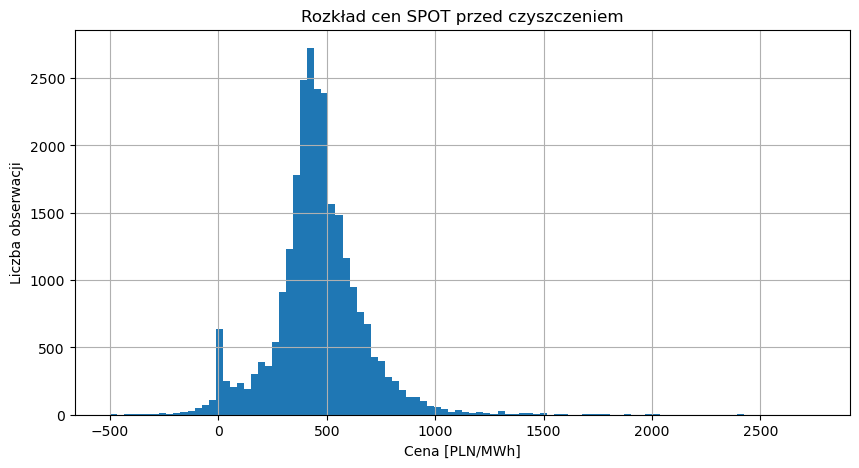

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(df_raw["price_spot"], bins=100)
plt.title("Rozkład cen SPOT przed czyszczeniem")
plt.xlabel("Cena [PLN/MWh]")
plt.ylabel("Liczba obserwacji")
plt.grid(True)
plt.show()

In [6]:
low_q = df_raw["price_spot"].quantile(0.01)
high_q = df_raw["price_spot"].quantile(0.99)

df_winsor = df_raw.copy()
df_winsor["price_spot_original"] = df_winsor["price_spot"]

df_winsor["price_spot"] = df_winsor["price_spot"].clip(
    lower=low_q,
    upper=high_q
)

df = df_winsor.copy()
del df["price_spot_original"]

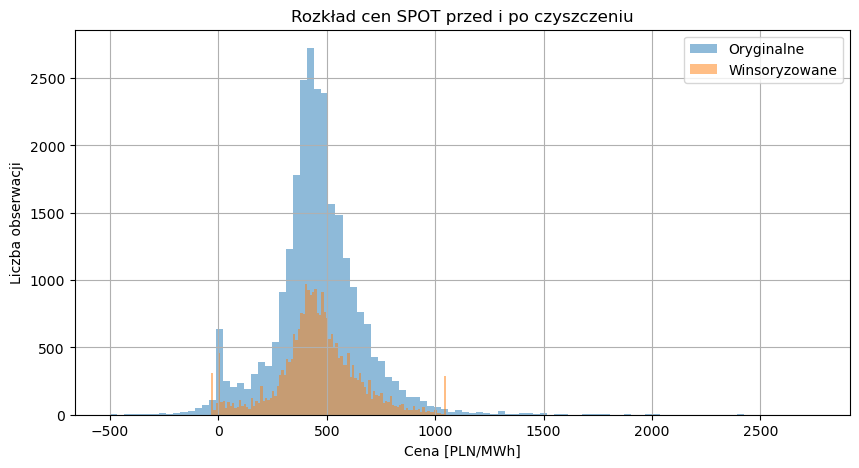

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(df_raw["price_spot"], bins=100, alpha=0.5, label="Oryginalne")
plt.hist(df_winsor["price_spot"], bins=100, alpha=0.5, label="Winsoryzowane")
plt.title("Rozkład cen SPOT przed i po czyszczeniu")
plt.xlabel("Cena [PLN/MWh]")
plt.ylabel("Liczba obserwacji")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
df = df_winsor.copy()
del df["price_spot_original"]

In [9]:
import requests

LAT = 52.2297
LON = 21.0122

def download_open_meteo_temperature(lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m"
        ],
        "timezone": "Europe/Warsaw"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    data = response.json()["hourly"]
    weather = pd.DataFrame(data)
    weather["timestamp"] = pd.to_datetime(weather["time"])
    weather = weather.drop(columns=["time"])
    
    return weather

In [10]:
weather_start = df["timestamp"].min().strftime("%Y-%m-%d")
weather_end = df["timestamp"].max().strftime("%Y-%m-%d")

weather = download_open_meteo_temperature(
    LAT,
    LON,
    weather_start,
    weather_end
)

In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

df = df.merge(weather, on="timestamp", how="left")

df.head()


,timestamp,price_spot,fw_gen,pv_gen,load,temperature_2m
0,2023-01-01 00:00:00,70.0,7903.43,0.0,14036.9,12.9
1,2023-01-01 01:00:00,30.0,7947.81,0.0,13135.5,13.2
2,2023-01-01 02:00:00,30.0,7943.87,0.0,12580.4,13.8
3,2023-01-01 03:00:00,30.0,7883.76,0.0,12110.1,13.8
4,2023-01-01 04:00:00,30.0,7794.12,0.0,11966.5,13.4


In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,price_spot,fw_gen,pv_gen,load,temperature_2m
0,2023-01-01 00:00:00,70.0,7903.43,0.0,14036.9,12.9
1,2023-01-01 01:00:00,30.0,7947.81,0.0,13135.5,13.2
2,2023-01-01 02:00:00,30.0,7943.87,0.0,12580.4,13.8
3,2023-01-01 03:00:00,30.0,7883.76,0.0,12110.1,13.8
4,2023-01-01 04:00:00,30.0,7794.12,0.0,11966.5,13.4


In [13]:
df = df.copy()

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").drop_duplicates(subset=["timestamp"]).reset_index(drop=True)

numeric_cols = ["price_spot", "load", "pv_gen", "fw_gen"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,timestamp,price_spot,fw_gen,pv_gen,load,temperature_2m
0,2023-01-01 00:00:00,70.0,7903.43,0.0,14036.9,12.9
1,2023-01-01 01:00:00,30.0,7947.81,0.0,13135.5,13.2
2,2023-01-01 02:00:00,30.0,7943.87,0.0,12580.4,13.8
3,2023-01-01 03:00:00,30.0,7883.76,0.0,12110.1,13.8
4,2023-01-01 04:00:00,30.0,7794.12,0.0,11966.5,13.4


In [14]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["dayofyear"] = df["timestamp"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

df["res_gen"] = df["fw_gen"] + df["pv_gen"]
df["residual_load"] = df["load"] - df["res_gen"]
df["res_share"] = df["res_gen"] / df["load"]
df["pv_share"] = df["pv_gen"] / df["load"]
df["fw_share"] = df["fw_gen"] / df["load"]

In [15]:
target = "price_spot"

price_lags = [24, 48, 72, 168]

for lag in price_lags:
    df[f"price_lag_{lag}h"] = df[target].shift(lag)

system_lags = [24, 48, 72, 168]

for lag in system_lags:
    df[f"load_lag_{lag}h"] = df["load"].shift(lag)
    df[f"pv_lag_{lag}h"] = df["pv_gen"].shift(lag)
    df[f"fw_lag_{lag}h"] = df["fw_gen"].shift(lag)
    df[f"residual_load_lag_{lag}h"] = df["residual_load"].shift(lag)

rolling_windows = [24, 48, 72, 168]

for window in rolling_windows:
    df[f"price_roll_mean_{window}h"] = df[target].shift(24).rolling(window).mean()
    df[f"price_roll_std_{window}h"] = df[target].shift(24).rolling(window).std()
    df[f"residual_load_roll_mean_{window}h"] = df["residual_load"].shift(24).rolling(window).mean()
    df[f"load_roll_mean_{window}h"] = df["load"].shift(24).rolling(window).mean()

In [16]:
pl_holidays = holidays.Poland(years=[2023, 2024, 2025, 2026])

df["date"] = df["timestamp"].dt.date
df["is_holiday"] = df["date"].isin(pl_holidays).astype(int)
df["is_weekend_or_holiday"] = ((df["is_weekend"] == 1) | (df["is_holiday"] == 1)).astype(int)

In [17]:
df_ml = df.dropna().copy()

In [18]:
df_ml = df_ml.sort_values("timestamp").copy()

train = df_ml[
    (df_ml["timestamp"] >= "2023-01-01") &
    (df_ml["timestamp"] < "2025-01-01")
].copy()

test = df_ml[
    (df_ml["timestamp"] >= "2025-01-01") &
    (df_ml["timestamp"] < "2026-01-01")
].copy()

target = "price_spot"

features = [
    col for col in df_ml.columns
    if col not in ["timestamp", "date", "price_spot"]
]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

non_numeric_cols = X_train.select_dtypes(exclude=["number"]).columns

features = [
    col for col in features
    if col not in non_numeric_cols
]

X_train = train[features]
X_test = test[features]

print("Train:", train["timestamp"].min(), "->", train["timestamp"].max(), X_train.shape)
print("Test:", test["timestamp"].min(), "->", test["timestamp"].max(), X_test.shape)
print("Usunięte nienumeryczne:", list(non_numeric_cols))

Train: 2023-01-08 23:00:00 -> 2024-12-31 23:00:00 (17352, 67)
Test: 2025-01-01 00:00:00 -> 2025-12-31 23:00:00 (8760, 67)
Usunięte nienumeryczne: ['date_dt']


In [19]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    epsilon = 1e-6

    smape = np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + epsilon)
    ) * 100

    return {
        "model": model_name,
        "MAE [PLN/MWh]": mae,
        "RMSE [PLN/MWh]": rmse,
        "sMAPE [%]": smape,
        "R2": r2
    }

In [20]:
models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=800,
        learning_rate=0.03,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}

if xgboost_available:
    models["XGBoost"] = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.02,
        max_depth=5,
        min_child_weight=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.1,
        random_state=42,
        objective="reg:squarederror"
    )

In [21]:
test_baseline = test.copy()
test_baseline["prediction_naive_24h"] = test_baseline["price_lag_24h"]

naive_mae = mean_absolute_error(
    test_baseline["price_spot"],
    test_baseline["prediction_naive_24h"]
)

naive_rmse = np.sqrt(mean_squared_error(
    test_baseline["price_spot"],
    test_baseline["prediction_naive_24h"]
))

print("Naive 24h MAE:", naive_mae)
print("Naive 24h RMSE:", naive_rmse)

Naive 24h MAE: 97.43265525114154
Naive 24h RMSE: 146.10381610613823


In [22]:
low_q = y_train.quantile(0.01)
high_q = y_train.quantile(0.99)

sample_weight = np.ones(len(y_train))

sample_weight[y_train <= low_q] = 3
sample_weight[y_train >= high_q] = 3

print("Próg niskich cen:", low_q)
print("Próg wysokich cen:", high_q)

Próg niskich cen: -3.3649
Próg wysokich cen: 1026.8274000000067


In [23]:
results = []
predictions = {}

for name, model in models.items():
    print("Trenuję:", name)

    if name == "MLP Neural Network":
        model.fit(X_train, y_train)

    elif isinstance(model, Pipeline):
        model.fit(X_train, y_train, model__sample_weight=sample_weight)

    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)

    y_pred = model.predict(X_test)

    predictions[name] = y_pred
    results.append(evaluate_model(y_test, y_pred, name))

results_df = pd.DataFrame(results).sort_values("MAE [PLN/MWh]")

naive_result = {
    "model": "Naive lag 24h",
    "MAE [PLN/MWh]": naive_mae,
    "RMSE [PLN/MWh]": naive_rmse,
    "sMAPE [%]": np.mean(
        2 * np.abs(test_baseline["prediction_naive_24h"] - test_baseline["price_spot"]) /
        (np.abs(test_baseline["price_spot"]) + np.abs(test_baseline["prediction_naive_24h"]) + 1e-6)
    ) * 100,
    "R2": r2_score(test_baseline["price_spot"], test_baseline["prediction_naive_24h"])
}

results_df = pd.concat(
    [results_df, pd.DataFrame([naive_result])],
    ignore_index=True
).sort_values("MAE [PLN/MWh]")

results_df

Trenuję: Ridge
Trenuję: Random Forest
Trenuję: Hist Gradient Boosting
Trenuję: XGBoost


,model,MAE [PLN/MWh],RMSE [PLN/MWh],sMAPE [%],R2
0,XGBoost,57.561214,79.844948,25.397743,0.842358
1,Hist Gradient Boosting,57.969055,80.483130,25.581008,0.839828
2,Random Forest,60.349381,83.108150,26.335062,0.829209
3,Ridge,63.504650,84.498082,25.353472,0.823449
4,Naive lag 24h,97.432655,146.103816,35.705545,0.472162


In [24]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
best_pred = predictions[best_model_name]

print("Najlepszy model:", best_model_name)

Najlepszy model: XGBoost


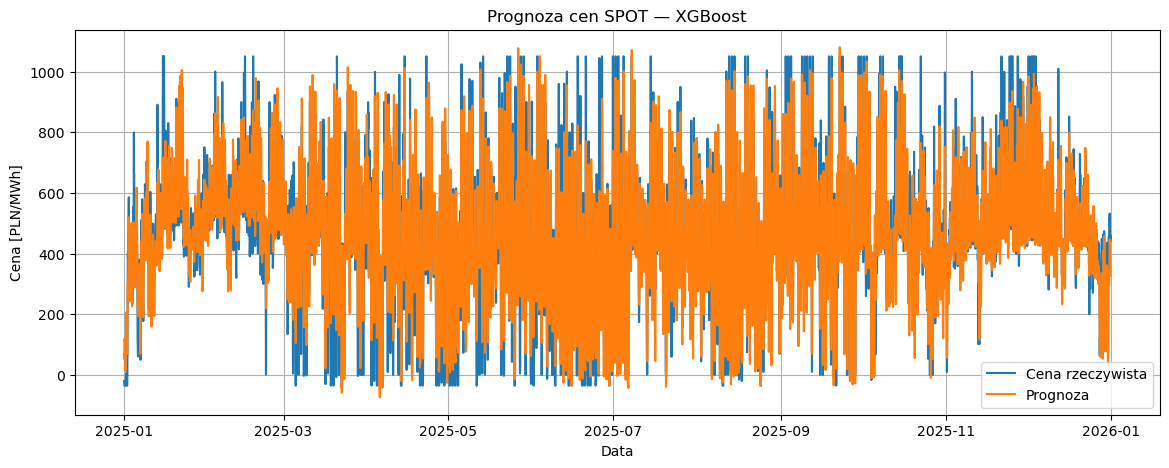

In [25]:
test_results = test[["timestamp", "price_spot"]].copy()
test_results["prediction"] = best_pred
test_results["error"] = test_results["price_spot"] - test_results["prediction"]
test_results["abs_error"] = test_results["error"].abs()

plt.figure(figsize=(14, 5))
plt.plot(test_results["timestamp"], test_results["price_spot"], label="Cena rzeczywista")
plt.plot(test_results["timestamp"], test_results["prediction"], label="Prognoza")
plt.title(f"Prognoza cen SPOT — {best_model_name}")
plt.xlabel("Data")
plt.ylabel("Cena [PLN/MWh]")
plt.legend()
plt.grid(True)
plt.show()

,feature,importance
22,price_lag_24h,0.305497
18,residual_load,0.224881
19,res_share,0.077564
25,price_lag_168h,0.050257
31,price_lag_24_vs_prev_day_mean,0.032016
21,fw_share,0.025728
8,dayofweek,0.022408
4,year,0.020297
62,price_roll_std_168h,0.016288
28,price_prev_day_max,0.014589


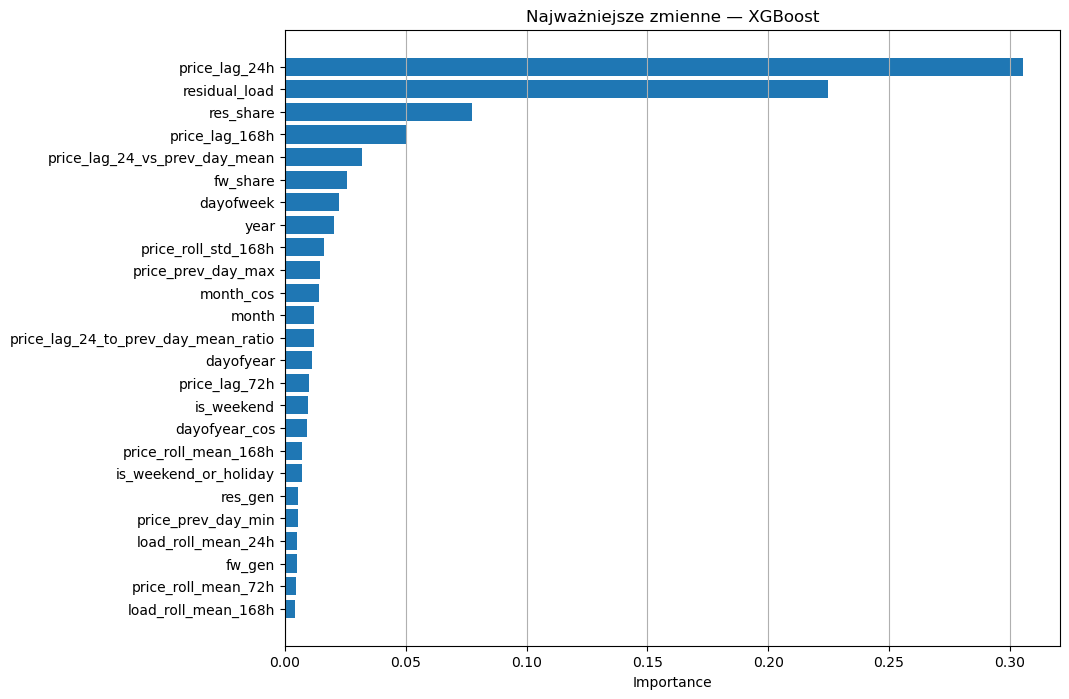

In [26]:
if best_model_name in ["Random Forest", "XGBoost"]:
    importances = pd.DataFrame({
        "feature": features,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importances.head(30))

    top_imp = importances.head(25)

    plt.figure(figsize=(10, 8))
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Najważniejsze zmienne — {best_model_name}")
    plt.xlabel("Importance")
    plt.grid(axis="x")
    plt.show()

else:
    print("Najlepszy model nie ma klasycznego feature_importances_.")

In [27]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

perm_importances = pd.DataFrame({
    "feature": features,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_importances.head(25)

,feature,importance
18,residual_load,78.836749
22,price_lag_24h,11.462331
19,res_share,5.100202
25,price_lag_168h,3.733250
17,res_gen,2.177957
36,residual_load_lag_24h,2.054009
35,fw_lag_24h,0.961119
63,residual_load_roll_mean_168h,0.905658
24,price_lag_72h,0.752608
47,fw_lag_168h,0.627194


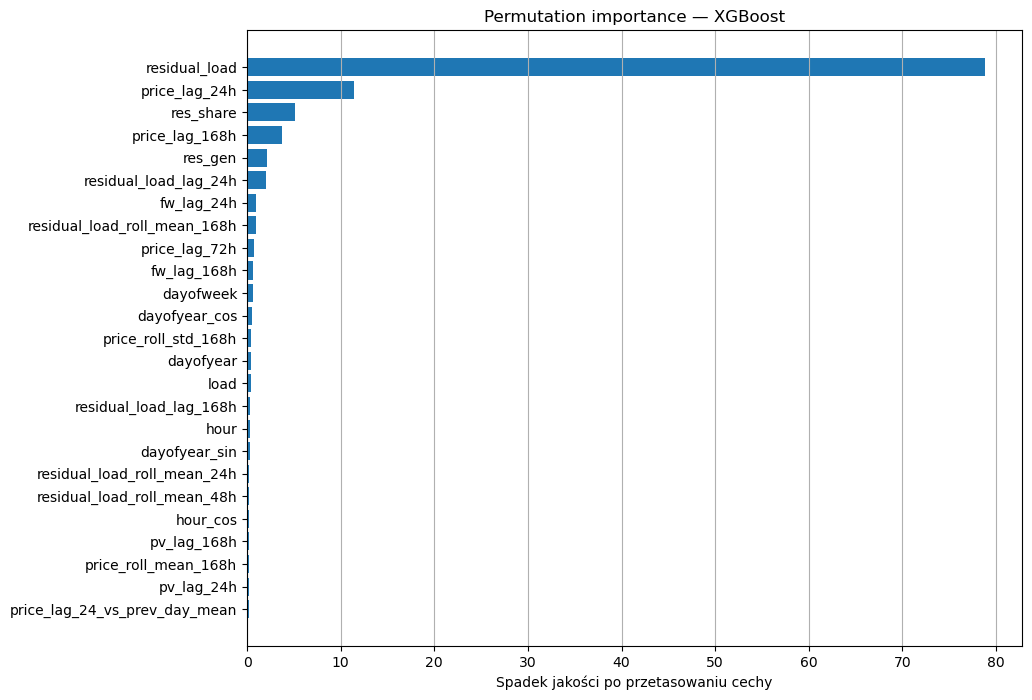

In [28]:
top_perm = perm_importances.head(25)

plt.figure(figsize=(10, 8))
plt.barh(top_perm["feature"], top_perm["importance"])
plt.gca().invert_yaxis()
plt.title(f"Permutation importance — {best_model_name}")
plt.xlabel("Spadek jakości po przetasowaniu cechy")
plt.grid(axis="x")
plt.show()

In [29]:
low_threshold = test_results["price_spot"].quantile(0.02)
high_threshold = test_results["price_spot"].quantile(0.98)

test_results["price_group"] = "normalne"

test_results.loc[
    test_results["price_spot"] <= low_threshold,
    "price_group"
] = "niskie ceny"

test_results.loc[
    test_results["price_spot"] >= high_threshold,
    "price_group"
] = "wysokie ceny"

extreme_metrics = (
    test_results
    .groupby("price_group")
    .agg(
        liczba_obserwacji=("price_spot", "count"),
        srednia_cena=("price_spot", "mean"),
        srednia_predykcja=("prediction", "mean"),
        MAE=("abs_error", "mean"),
        mediana_bledu=("abs_error", "median"),
        max_blad=("abs_error", "max")
    )
    .reset_index()
)

extreme_metrics

,price_group,liczba_obserwacji,srednia_cena,srednia_predykcja,MAE,mediana_bledu,max_blad
0,niskie ceny,176,-34.317216,33.122223,69.168202,61.149601,236.456207
1,normalne,8408,438.849277,434.206512,55.153906,39.714371,421.073456
2,wysokie ceny,176,1027.482045,867.407166,160.957919,131.852582,482.092224


In [30]:
test_results["month"] = test_results["timestamp"].dt.month
test_results["year_month"] = test_results["timestamp"].dt.to_period("M").astype(str)

monthly_errors = (
    test_results
    .groupby("year_month")
    .agg(
        MAE=("abs_error", "mean"),
        RMSE=("error", lambda x: np.sqrt(np.mean(x**2))),
        srednia_cena=("price_spot", "mean"),
        srednia_predykcja=("prediction", "mean")
    )
    .reset_index()
)

monthly_errors

,year_month,MAE,RMSE,srednia_cena,srednia_predykcja
0,2025-01,64.461924,88.628994,479.046358,469.736176
1,2025-02,52.017768,69.072362,561.921473,574.937988
2,2025-03,57.371988,82.335951,417.287608,441.803467
3,2025-04,53.147716,72.715206,378.031653,392.544067
4,2025-05,65.986726,88.792289,402.204099,389.704681
5,2025-06,69.672748,93.634481,348.879667,329.703308
6,2025-07,51.525656,72.268241,435.123763,412.270660
7,2025-08,49.716335,71.102685,384.552715,373.134369
8,2025-09,51.200279,71.154216,445.870778,426.068909
9,2025-10,61.257383,84.807253,439.775968,428.316071


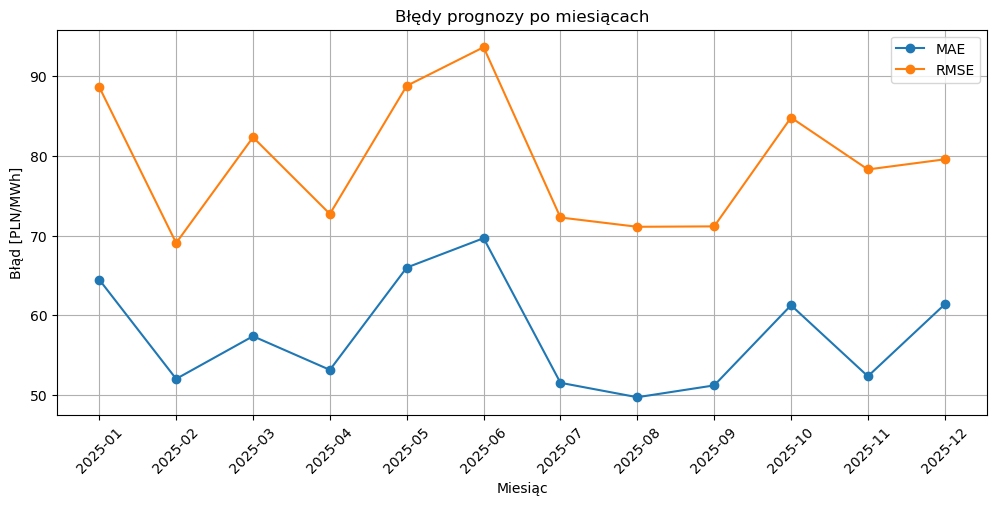

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_errors["year_month"], monthly_errors["MAE"], marker="o", label="MAE")
plt.plot(monthly_errors["year_month"], monthly_errors["RMSE"], marker="o", label="RMSE")
plt.title("Błędy prognozy po miesiącach")
plt.xlabel("Miesiąc")
plt.ylabel("Błąd [PLN/MWh]")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [32]:
test_results["date"] = test_results["timestamp"].dt.date

daily_errors = (
    test_results
    .groupby("date")
    .agg(MAE=("abs_error", "mean"))
    .reset_index()
    .sort_values("MAE", ascending=False)
)

worst_day = daily_errors.iloc[0]["date"]

print("Dzień z największym MAE:", worst_day)
daily_errors.head(10)

Dzień z największym MAE: 2025-01-15


,date,MAE
14,2025-01-15,246.951260
239,2025-08-28,142.694206
364,2025-12-31,139.157076
328,2025-11-25,130.072442
167,2025-06-17,120.499591
136,2025-05-17,119.167582
144,2025-05-25,116.988918
283,2025-10-11,116.789886
176,2025-06-26,116.268432
0,2025-01-01,116.106737


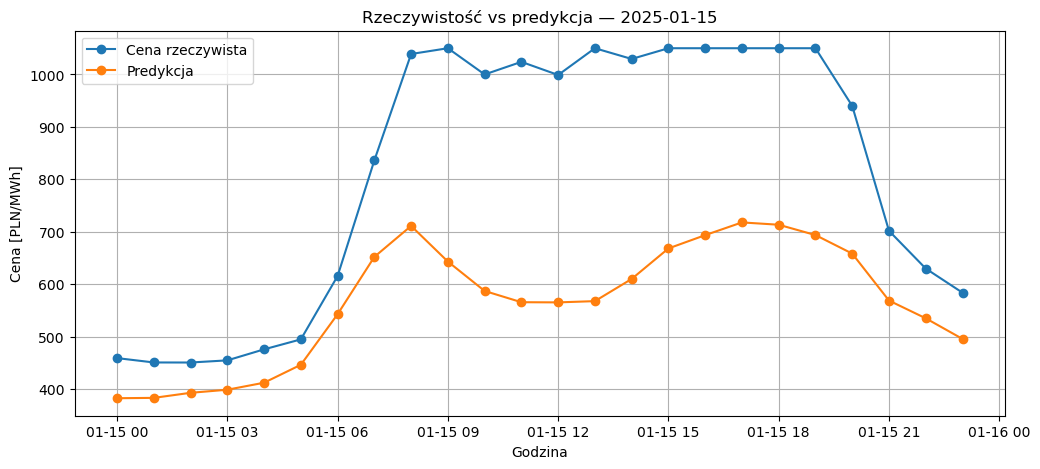

In [33]:
one_day = test_results[test_results["date"] == worst_day].copy()

plt.figure(figsize=(12, 5))
plt.plot(one_day["timestamp"], one_day["price_spot"], marker="o", label="Cena rzeczywista")
plt.plot(one_day["timestamp"], one_day["prediction"], marker="o", label="Predykcja")
plt.title(f"Rzeczywistość vs predykcja — {worst_day}")
plt.xlabel("Godzina")
plt.ylabel("Cena [PLN/MWh]")
plt.legend()
plt.grid(True)
plt.show()

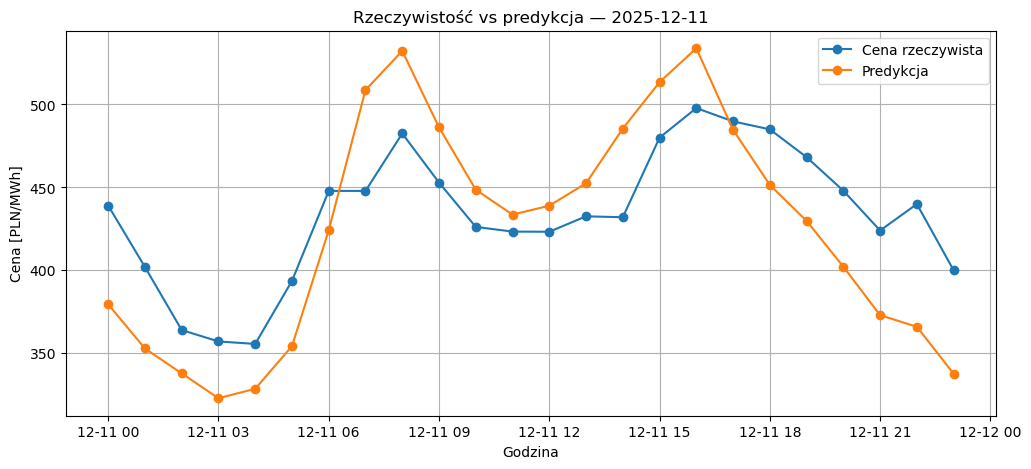

In [34]:
selected_day = "2025-12-11"

one_day = test_results[test_results["timestamp"].dt.date == pd.to_datetime(selected_day).date()].copy()

plt.figure(figsize=(12, 5))
plt.plot(one_day["timestamp"], one_day["price_spot"], marker="o", label="Cena rzeczywista")
plt.plot(one_day["timestamp"], one_day["prediction"], marker="o", label="Predykcja")
plt.title(f"Rzeczywistość vs predykcja — {selected_day}")
plt.xlabel("Godzina")
plt.ylabel("Cena [PLN/MWh]")
plt.legend()
plt.grid(True)
plt.show()

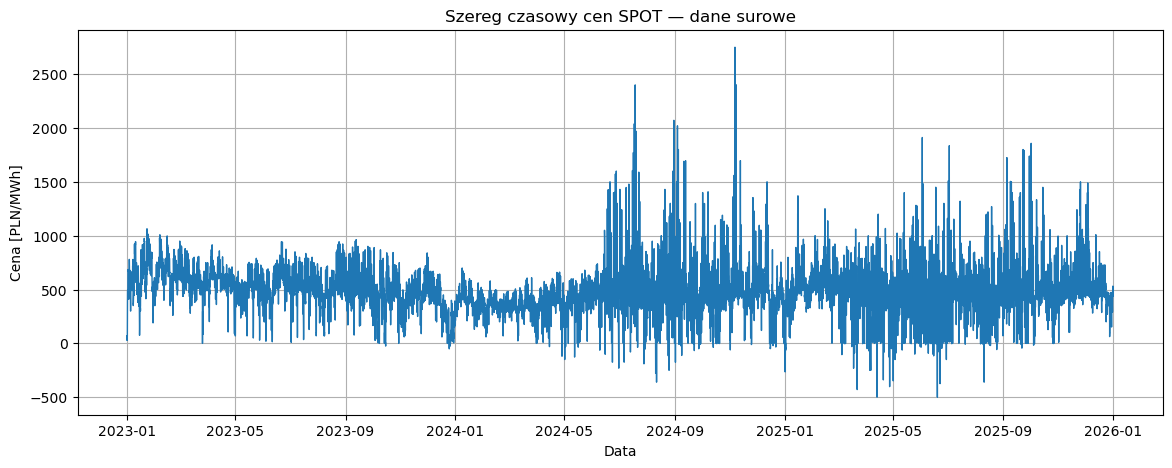

In [35]:
plt.figure(figsize=(14, 5))
plt.plot(df_raw["timestamp"], df_raw["price_spot"], linewidth=1)
plt.title("Szereg czasowy cen SPOT — dane surowe")
plt.xlabel("Data")
plt.ylabel("Cena [PLN/MWh]")
plt.grid(True)
plt.show()

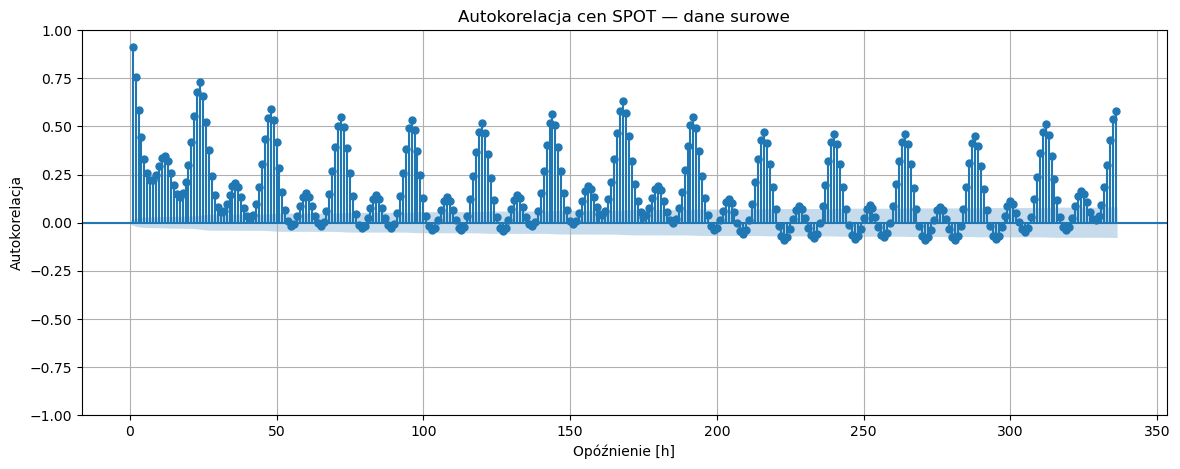

In [36]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    df_raw["price_spot"].dropna(),
    lags=24*14,
    ax=ax,
    zero=False
)

ax.set_title("Autokorelacja cen SPOT — dane surowe")
ax.set_xlabel("Opóźnienie [h]")
ax.set_ylabel("Autokorelacja")
ax.grid(True)

plt.show()

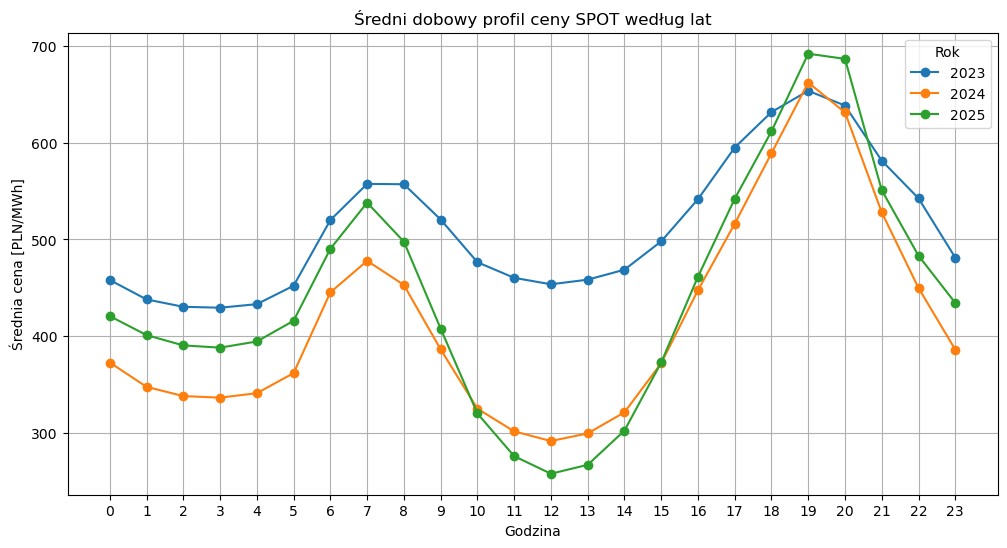

In [37]:
temp = df_raw.copy()

temp["year"] = temp["timestamp"].dt.year
temp["hour"] = temp["timestamp"].dt.hour

avg_hour_year = (
    temp
    .groupby(["year", "hour"])["price_spot"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for year in sorted(avg_hour_year["year"].unique()):
    data_year = avg_hour_year[avg_hour_year["year"] == year]
    
    plt.plot(
        data_year["hour"],
        data_year["price_spot"],
        marker="o",
        label=str(year)
    )

plt.title("Średni dobowy profil ceny SPOT według lat")
plt.xlabel("Godzina")
plt.ylabel("Średnia cena [PLN/MWh]")
plt.xticks(range(0, 24))
plt.legend(title="Rok")
plt.grid(True)
plt.show()

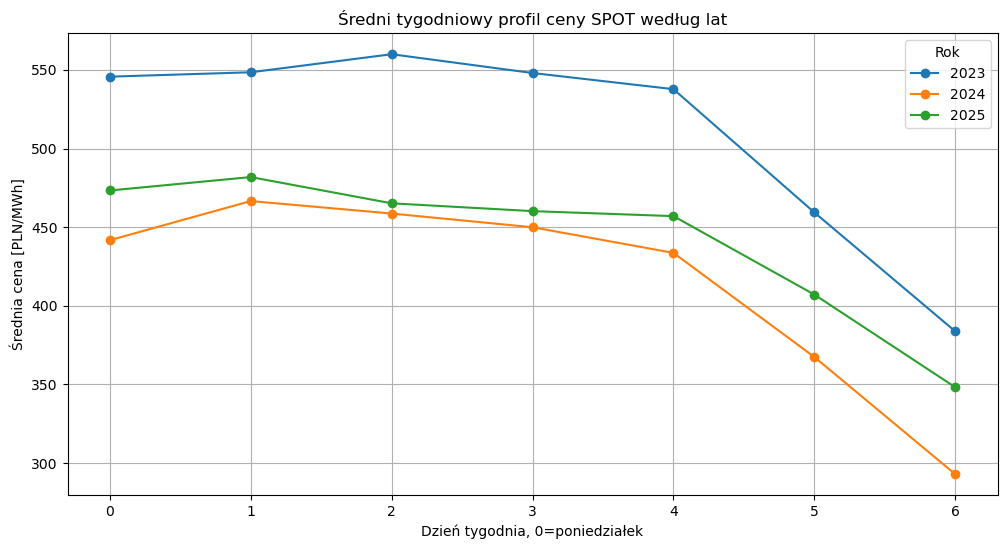

In [38]:
temp = df_raw.copy()

temp["year"] = temp["timestamp"].dt.year
temp["dayofweek"] = temp["timestamp"].dt.dayofweek

avg_week_year = (
    temp
    .groupby(["year", "dayofweek"])["price_spot"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(12, 6))

for year in sorted(avg_week_year["year"].unique()):
    data_year = avg_week_year[avg_week_year["year"] == year]
    
    plt.plot(
        data_year["dayofweek"],
        data_year["price_spot"],
        marker="o",
        label=str(year)
    )

plt.title("Średni tygodniowy profil ceny SPOT według lat")
plt.xlabel("Dzień tygodnia, 0=poniedziałek")
plt.ylabel("Średnia cena [PLN/MWh]")
plt.xticks(range(0, 7))
plt.legend(title="Rok")
plt.grid(True)
plt.show()

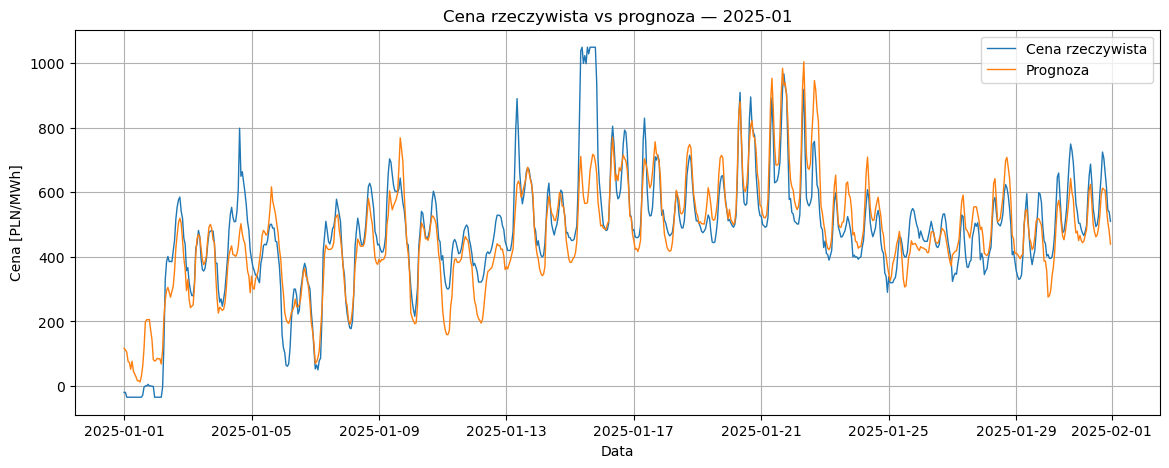

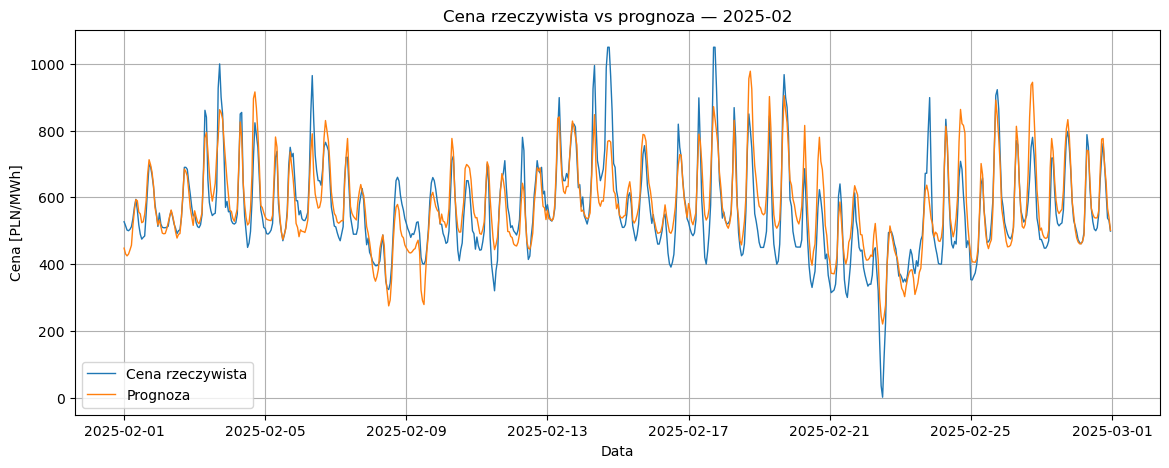

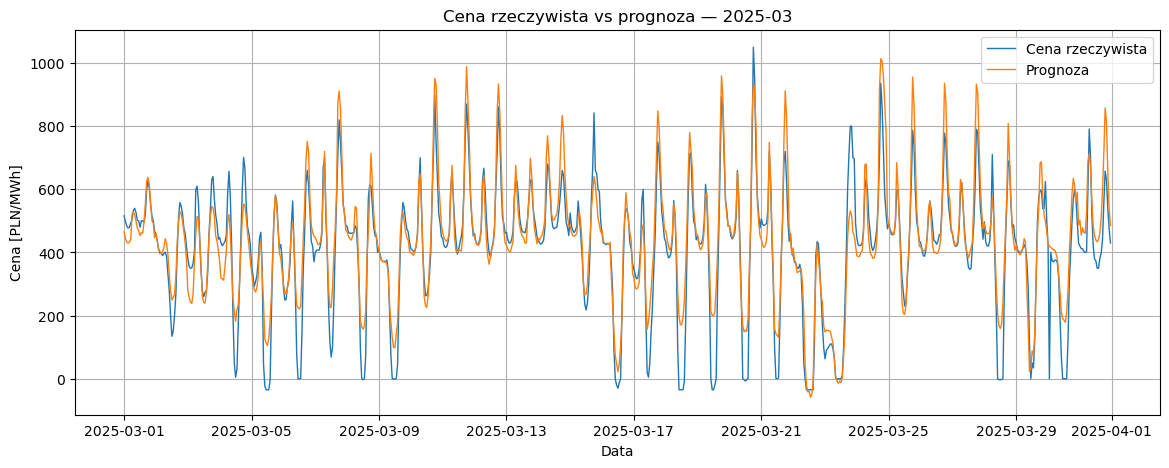

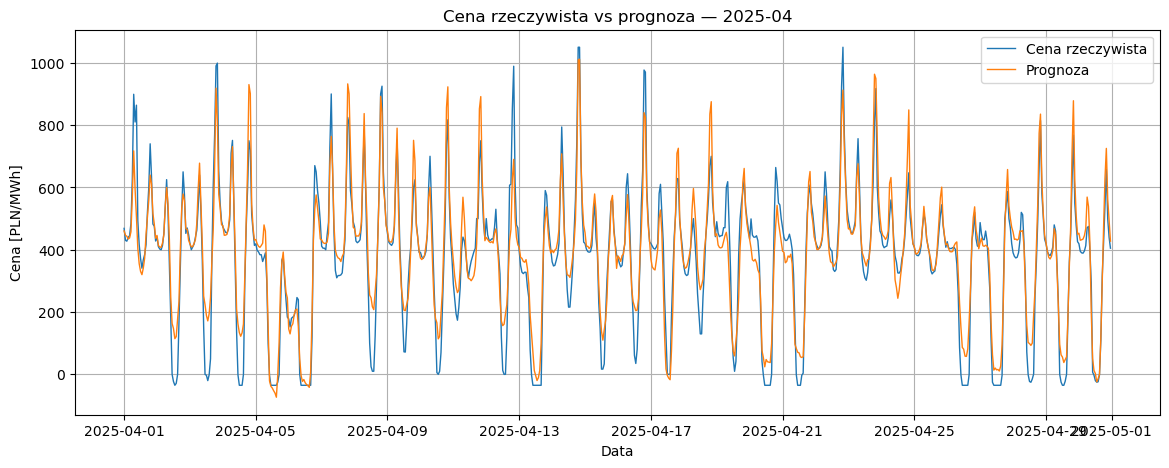

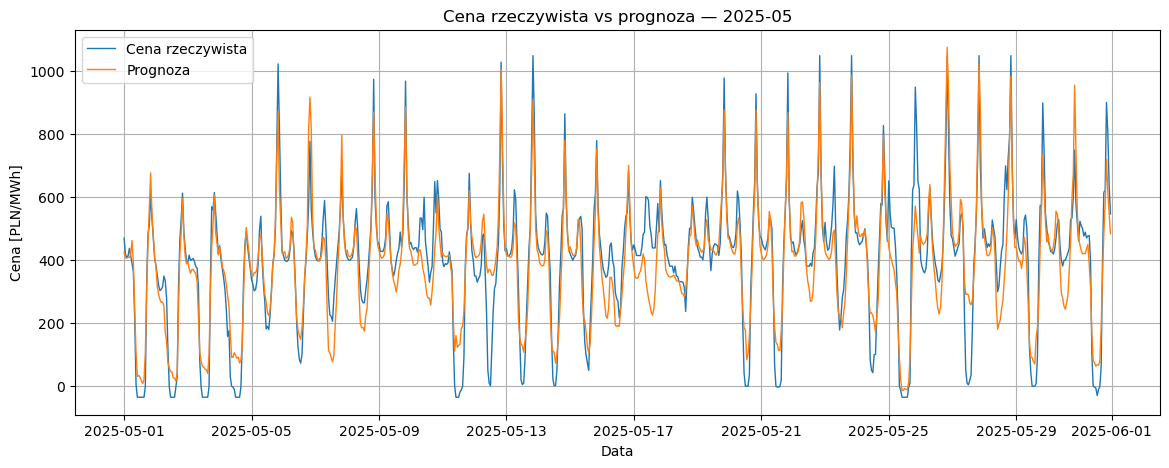

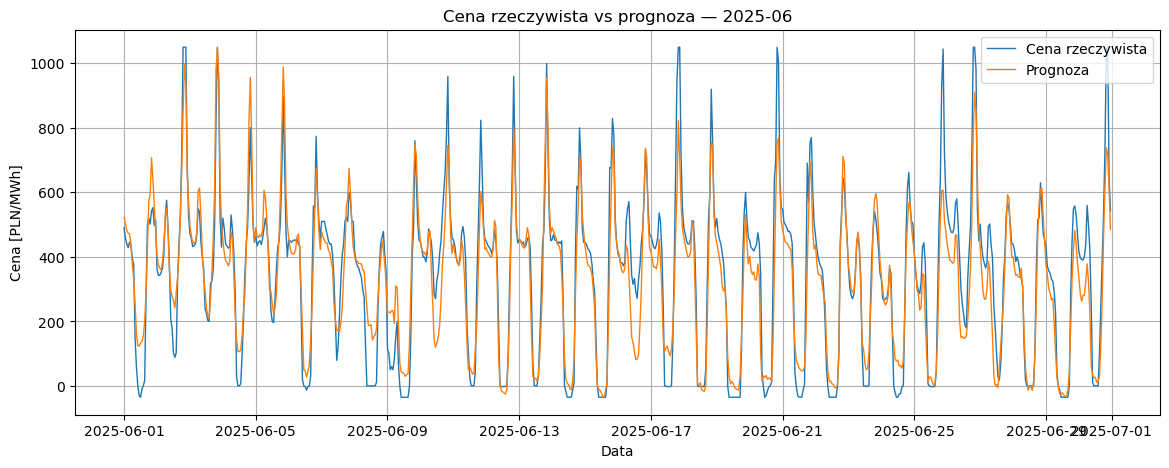

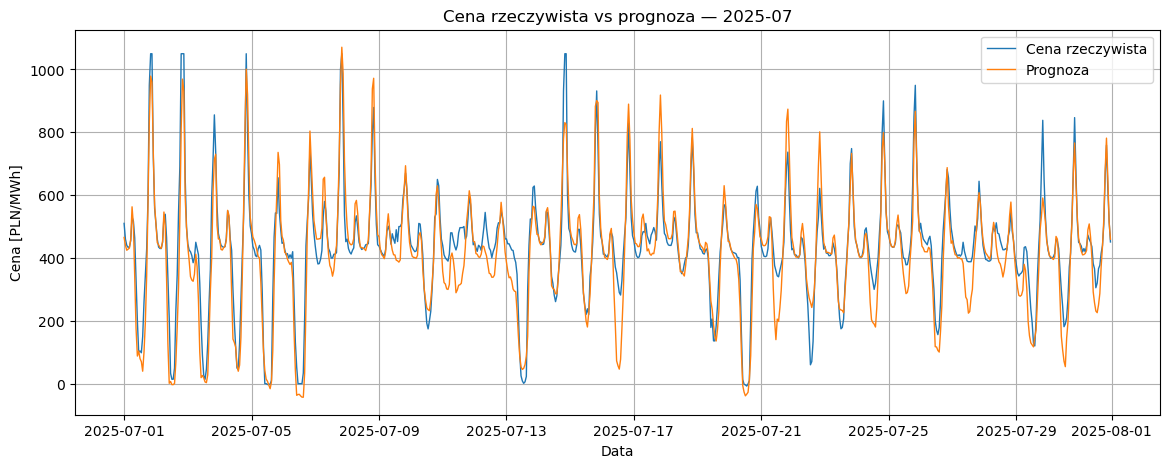

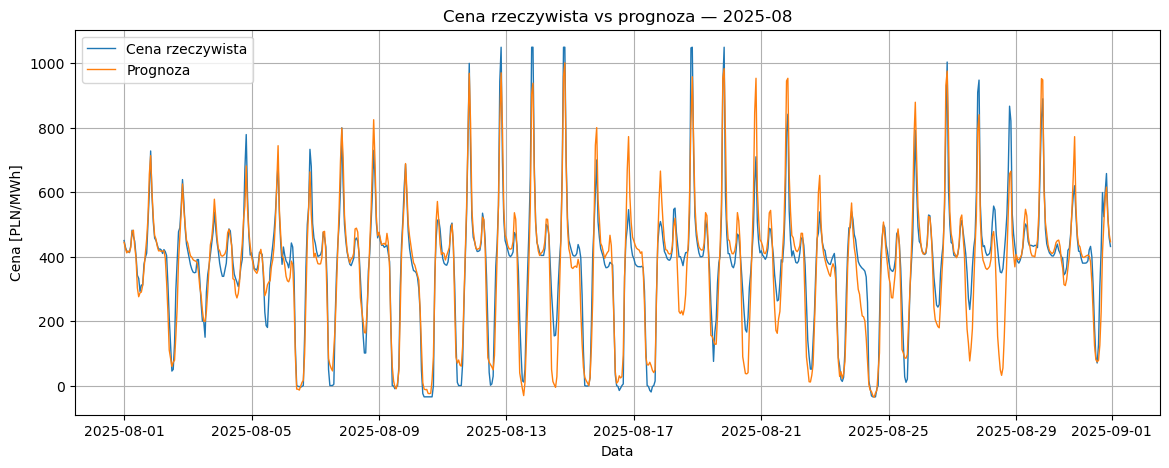

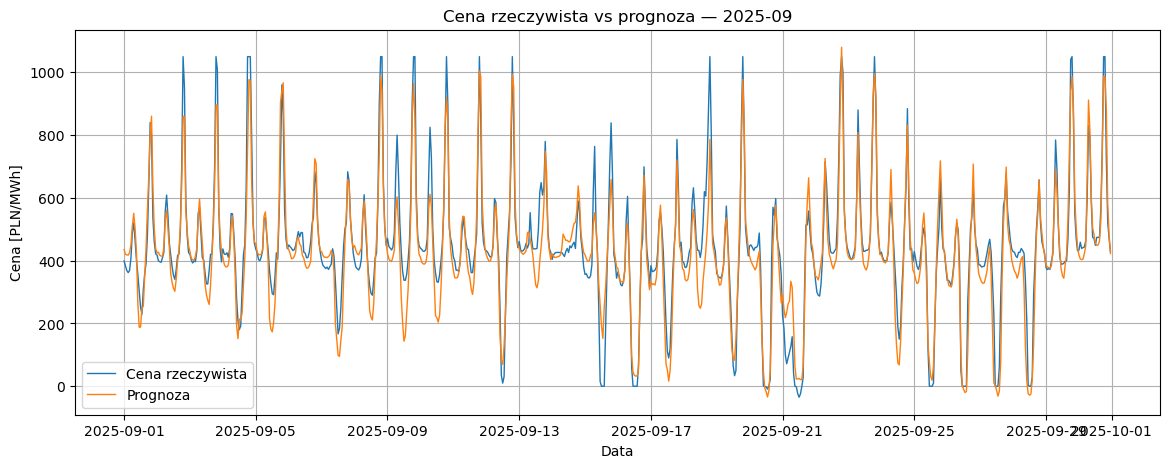

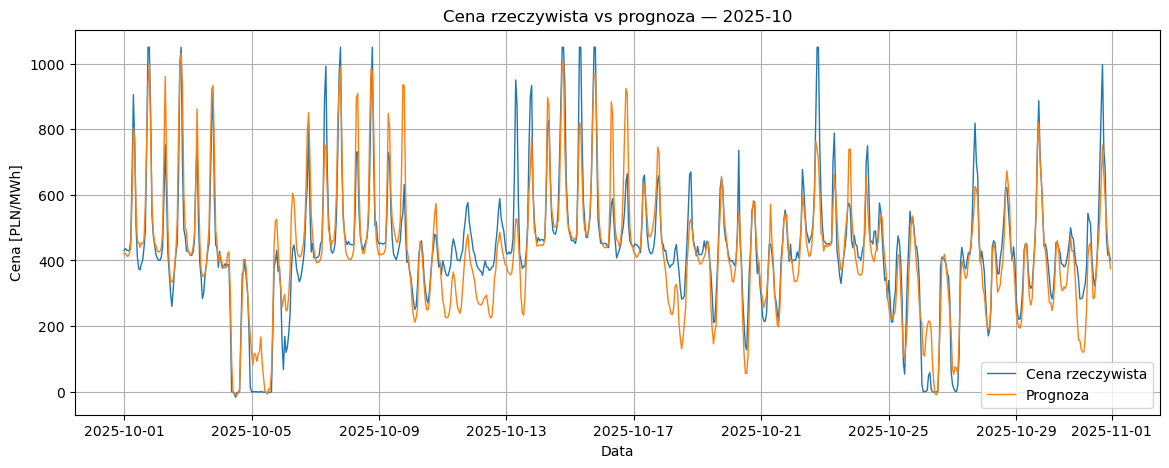

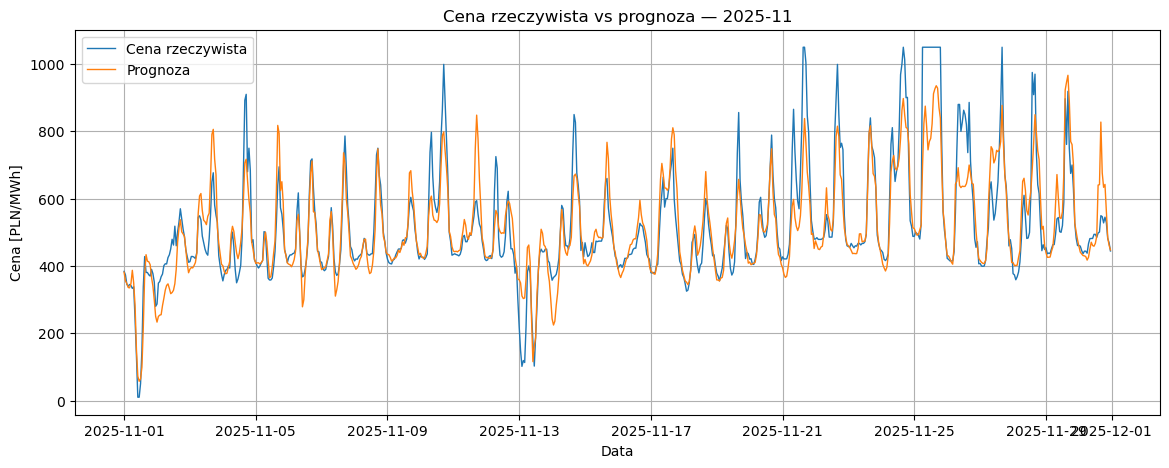

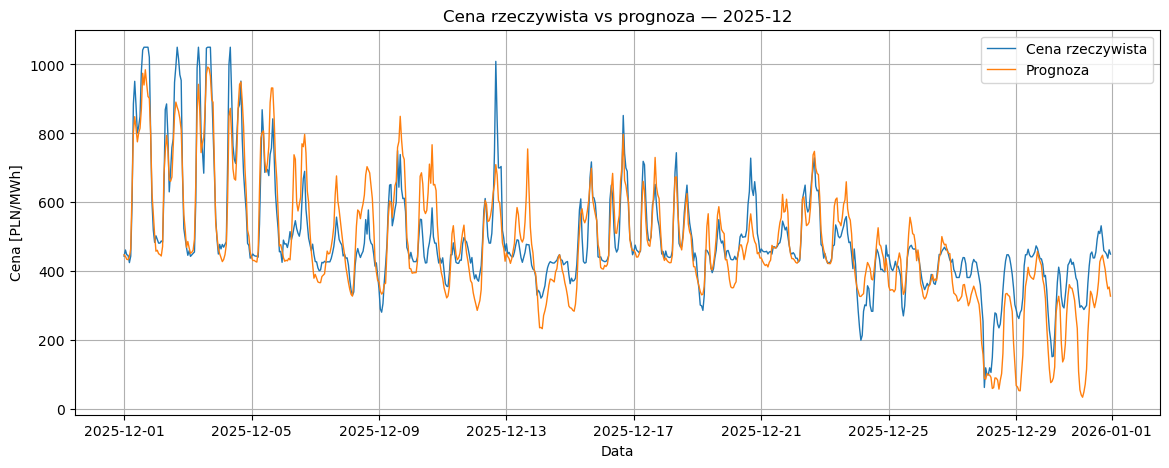

In [39]:
test_results["year_month"] = test_results["timestamp"].dt.to_period("M").astype(str)

for month in test_results["year_month"].unique():
    month_data = test_results[test_results["year_month"] == month]

    plt.figure(figsize=(14, 5))
    plt.plot(month_data["timestamp"], month_data["price_spot"], label="Cena rzeczywista", linewidth=1)
    plt.plot(month_data["timestamp"], month_data["prediction"], label="Prognoza", linewidth=1)
    plt.title(f"Cena rzeczywista vs prognoza — {month}")
    plt.xlabel("Data")
    plt.ylabel("Cena [PLN/MWh]")
    plt.legend()
    plt.grid(True)
    plt.show()

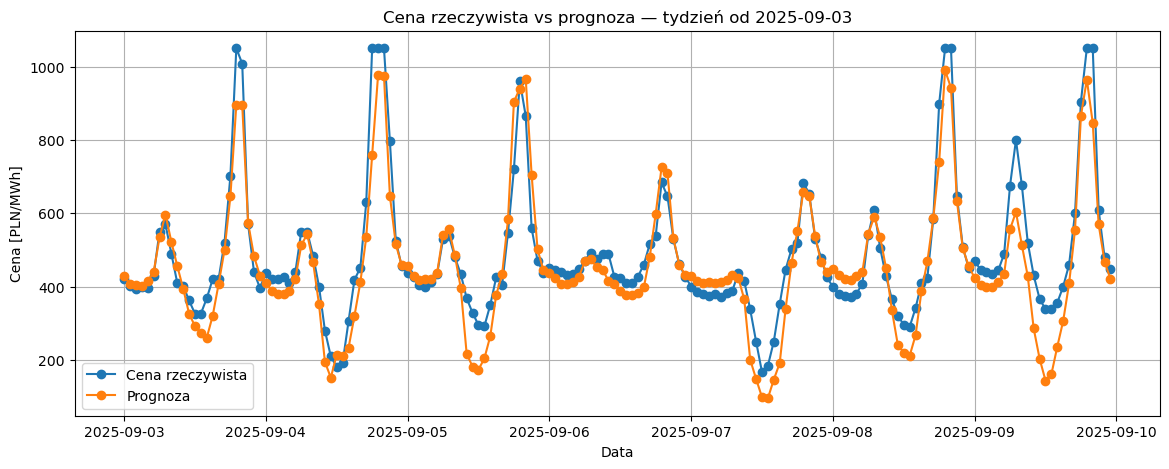

In [40]:
selected_start = "2025-09-03"
selected_end = "2025-09-10"

week_data = test_results[
    (test_results["timestamp"] >= selected_start) &
    (test_results["timestamp"] < selected_end)
].copy()

plt.figure(figsize=(14, 5))
plt.plot(week_data["timestamp"], week_data["price_spot"], marker="o", label="Cena rzeczywista")
plt.plot(week_data["timestamp"], week_data["prediction"], marker="o", label="Prognoza")
plt.title(f"Cena rzeczywista vs prognoza — tydzień od {selected_start}")
plt.xlabel("Data")
plt.ylabel("Cena [PLN/MWh]")
plt.legend()
plt.grid(True)
plt.show()

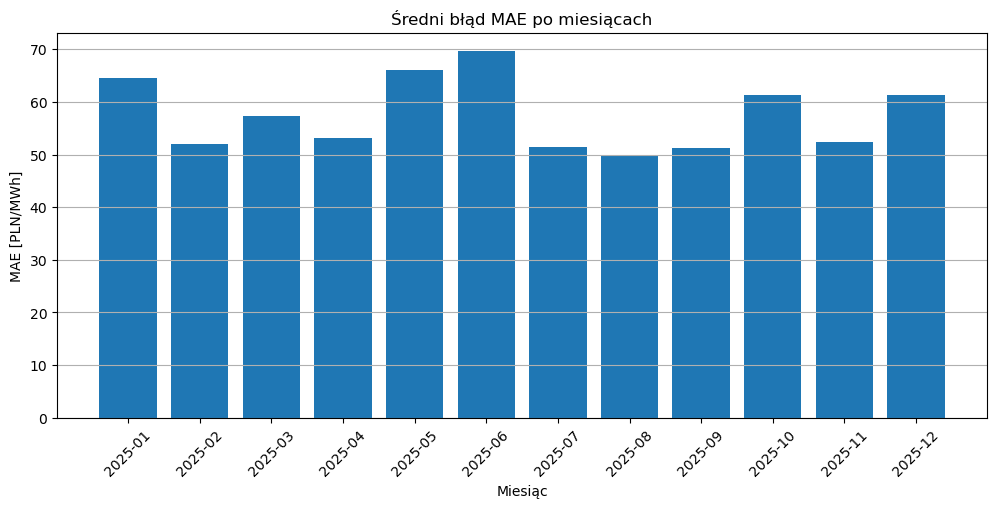

In [41]:
test_results["abs_error"] = (test_results["price_spot"] - test_results["prediction"]).abs()
test_results["year_month"] = test_results["timestamp"].dt.to_period("M").astype(str)

monthly_error = (
    test_results
    .groupby("year_month")["abs_error"]
    .mean()
    .reset_index(name="MAE")
)

plt.figure(figsize=(12, 5))
plt.bar(monthly_error["year_month"], monthly_error["MAE"])
plt.title("Średni błąd MAE po miesiącach")
plt.xlabel("Miesiąc")
plt.ylabel("MAE [PLN/MWh]")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [42]:
test_results["error"] = test_results["price_spot"] - test_results["prediction"]

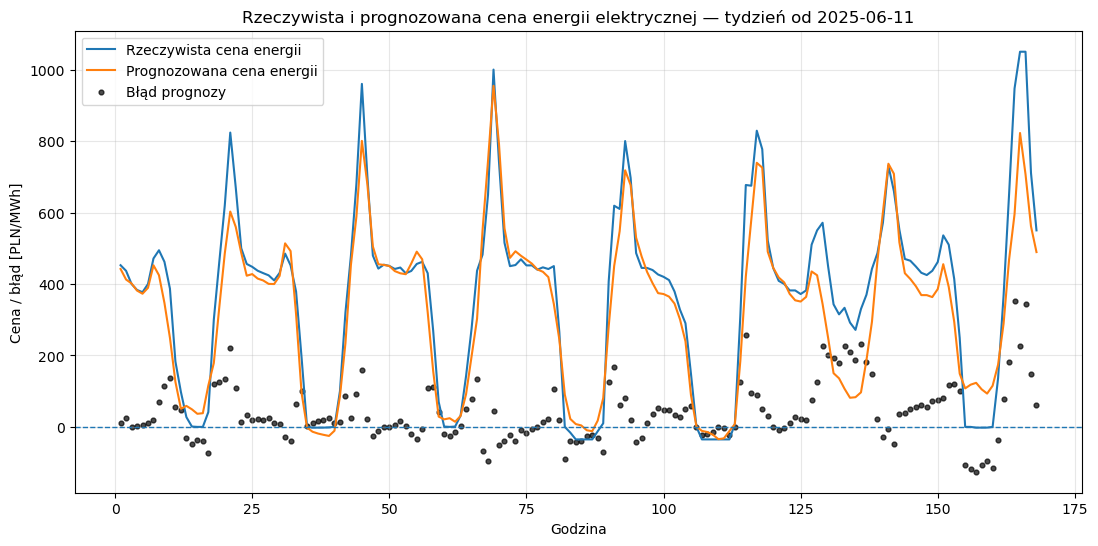

In [43]:
selected_start = "2025-06-11"
selected_end = "2025-06-18"

week_data = test_results[
    (test_results["timestamp"] >= selected_start) &
    (test_results["timestamp"] < selected_end)
].copy()

week_data = week_data.reset_index(drop=True)
week_data["hour_no"] = np.arange(1, len(week_data) + 1)

plt.figure(figsize=(13, 6))

plt.plot(
    week_data["hour_no"],
    week_data["price_spot"],
    label="Rzeczywista cena energii",
    linewidth=1.5
)

plt.plot(
    week_data["hour_no"],
    week_data["prediction"],
    label="Prognozowana cena energii",
    linewidth=1.5
)

plt.scatter(
    week_data["hour_no"],
    week_data["error"],
    label="Błąd prognozy",
    s=12,
    alpha=0.7,
    color = "black"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Rzeczywista i prognozowana cena energii elektrycznej — tydzień od {selected_start}")
plt.xlabel("Godzina")
plt.ylabel("Cena / błąd [PLN/MWh]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
import joblib

model_package = {
    "best_model_name": best_model_name,
    "best_model": best_model,
    "features": features,
    "target": target,
    "results_df": results_df,
    "low_q_winsor": low_q,
    "high_q_winsor": high_q
}

#joblib.dump(model_package, "spot_price_forecast_model.pkl")

print("Zapisano model do pliku: spot_price_forecast_model.pkl")

Zapisano model do pliku: spot_price_forecast_model.pkl
